In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Employee Data Analysis") \
    .getOrCreate()

print("Spark Session Started Successfully!")

Spark Session Started Successfully!


In [2]:
df = spark.read.csv("employee_salary_dataset.csv", header=True, inferSchema=True)

print("Dataset Loaded! Total Rows:", df.count())
df.show(5)

Dataset Loaded! Total Rows: 50
+----------+----------+----------+----------------+---------------+---+------+---------+--------------+
|EmployeeID|      Name|Department|Experience_Years|Education_Level|Age|Gender|     City|Monthly_Salary|
+----------+----------+----------+----------------+---------------+---+------+---------+--------------+
|         1|Employee_1| Marketing|              15|         Master| 53|Female|    Delhi|        111416|
|         2|Employee_2|Operations|               7|       Bachelor| 25|Female|Bangalore|         95271|
|         3|Employee_3|        IT|              12|    High School| 51|Female|Hyderabad|         69064|
|         4|Employee_4|Operations|               8|            PhD| 44|  Male|    Delhi|         95091|
|         5|Employee_5|Operations|              15|         Master| 36|Female|    Delhi|        132450|
+----------+----------+----------+----------------+---------------+---+------+---------+--------------+
only showing top 5 rows


In [3]:
# View column types
df.printSchema()

# Drop rows with any null values
df_clean = df.dropna()

print("Rows after cleaning:", df_clean.count())

root
 |-- EmployeeID: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Department: string (nullable = true)
 |-- Experience_Years: integer (nullable = true)
 |-- Education_Level: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Monthly_Salary: integer (nullable = true)

Rows after cleaning: 50


In [4]:
from pyspark.sql.functions import avg, round

avg_salary = df_clean.groupBy("Department") \
    .agg(round(avg("Monthly_Salary"), 2).alias("Avg_Salary")) \
    .orderBy("Avg_Salary", ascending=False)

print("=== Average Salary Per Department ===")
avg_salary.show()

=== Average Salary Per Department ===
+----------+----------+
|Department|Avg_Salary|
+----------+----------+
| Marketing|  96430.85|
|Operations|   84239.9|
|        HR|  82945.14|
|        IT|   76520.5|
|   Finance|   67261.9|
+----------+----------+



In [5]:
# Define threshold — e.g., salary > 100,000
high_salary = df_clean.filter(df_clean["Monthly_Salary"] > 100000)

print("=== High Salary Employees (> 100,000) ===")
high_salary.select("Name", "Department", "Monthly_Salary").show()
print("Total High Salary Employees:", high_salary.count())

=== High Salary Employees (> 100,000) ===
+-----------+----------+--------------+
|       Name|Department|Monthly_Salary|
+-----------+----------+--------------+
| Employee_1| Marketing|        111416|
| Employee_5|Operations|        132450|
|Employee_11| Marketing|        141381|
|Employee_12|        IT|        104909|
|Employee_16|   Finance|        101213|
|Employee_23| Marketing|        122888|
|Employee_25|        HR|        132455|
|Employee_27|        IT|        119660|
|Employee_28|   Finance|        118179|
|Employee_33| Marketing|        127946|
|Employee_34|        HR|        134616|
|Employee_35|        IT|        130983|
|Employee_38|Operations|        149123|
|Employee_41| Marketing|        107989|
|Employee_50| Marketing|        121752|
+-----------+----------+--------------+

Total High Salary Employees: 15


In [6]:
sorted_by_exp = df_clean.orderBy("Experience_Years", ascending=False)

print("=== Employees Sorted by Experience (High to Low) ===")
sorted_by_exp.select("Name", "Department", "Experience_Years", "Monthly_Salary").show(10)

=== Employees Sorted by Experience (High to Low) ===
+-----------+----------+----------------+--------------+
|       Name|Department|Experience_Years|Monthly_Salary|
+-----------+----------+----------------+--------------+
|Employee_43| Marketing|              19|         68525|
|Employee_10|Operations|              18|         31893|
|Employee_17| Marketing|              18|         30895|
|Employee_30| Marketing|              18|         99543|
| Employee_8|        IT|              17|         44830|
|Employee_44|   Finance|              17|         72202|
|Employee_23| Marketing|              16|        122888|
|Employee_28|   Finance|              16|        118179|
| Employee_1| Marketing|              15|        111416|
|Employee_24|        HR|              15|         64790|
+-----------+----------+----------------+--------------+
only showing top 10 rows


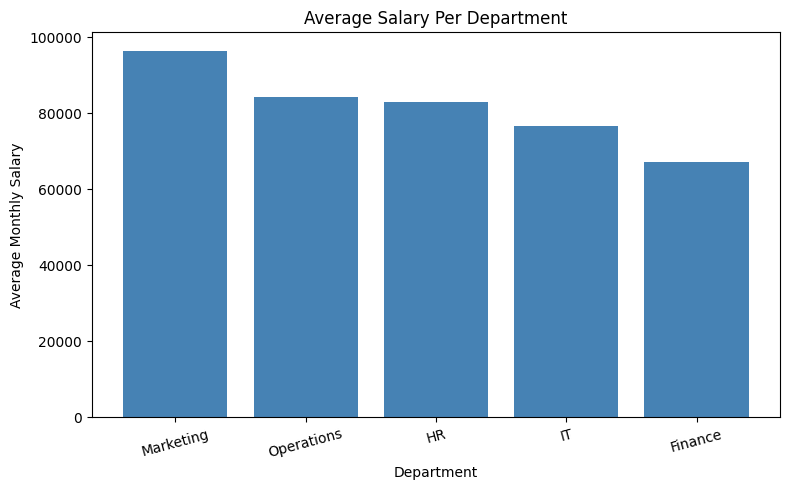

In [7]:
import matplotlib.pyplot as plt

# Convert PySpark DataFrame to Pandas for plotting
avg_salary_pd = avg_salary.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(avg_salary_pd["Department"], avg_salary_pd["Avg_Salary"], color="steelblue")
plt.title("Average Salary Per Department")
plt.xlabel("Department")
plt.ylabel("Average Monthly Salary")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("avg_salary_chart.png")  # saves chart for submission
plt.show()

In [8]:
spark.stop()
print("Spark Session Stopped.")

Spark Session Stopped.
